<a href="https://colab.research.google.com/github/Karima-mtq/Basemap/blob/main/datasets_evaluation_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install cartopy
import cartopy

In [ ]:
!pip install netCDF4
!pip install eofs
!pip install Basemap

In [ ]:
%matplotlib inline
import xarray as xr
import os
from scipy import signal
from netCDF4 import Dataset
from mpl_toolkits.basemap import Basemap
from eofs.standard import Eof
from netCDF4 import num2date
import numpy as np
import numpy.polynomial.polynomial as poly
import netCDF4 as netcdf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
import glob

In [ ]:
!ls

EOFs_PCs_Free_clean.nc	    EOFs_PCs_ODA_clean.nc		   sample_data
EOFs_PCs_NudA_UVT_clean.nc  HadISST_EOFs_PCs_1980_2010_10modes.nc


In [ ]:
datasets = {
    "FREE": xr.open_dataset("/content/EOFs_PCs_Free_clean.nc"),
    "ODA": xr.open_dataset("/content/EOFs_PCs_ODA_clean.nc"),
    "HADLEY": xr.open_dataset("/content/HadISST_EOFs_PCs_1980_2010_10modes.nc"),
    "NUDA_UVT": xr.open_dataset("/content/EOFs_PCs_NudA_UVT_clean.nc"),
}


In [ ]:
def convert_time(time_array):
    if isinstance(time_array[0], cftime.DatetimeNoLeap):
        return pd.to_datetime([t.strftime("%Y-%m-%d") for t in time_array])
    else:
        return pd.to_datetime(time_array)


In [ ]:
nmodes = 5
cmap = "RdBu_r"


In [ ]:
pc_min, pc_max = np.inf, -np.inf

for key in ["FREE", "ODA", "HADLEY", "NUDA_UVT"]:
    pcs = datasets[key]["PCs"].values[:, :nmodes]

    # Standardisation : diviser chaque mode par son écart-type
    pcs_std = pcs / np.std(pcs, axis=0, keepdims=True)

    pc_min = min(pc_min, pcs_std.min())
    pc_max = max(pc_max, pcs_std.max())

margin = 0.1 * (pc_max - pc_min)
pc_ylim = (pc_min - margin, pc_max + margin)



In [ ]:
pc_styles = {
    "FREE":     {"color": "black",   "linestyle": "-",  "linewidth": 2},
    "ODA":      {"color": "red",     "linestyle": "--", "linewidth": 2},
    "HADLEY":   {"color": "blue",    "linestyle": ":",  "linewidth": 2},
    "NUDA_UVT": {"color": "green",   "linestyle": "-.", "linewidth": 2},
}


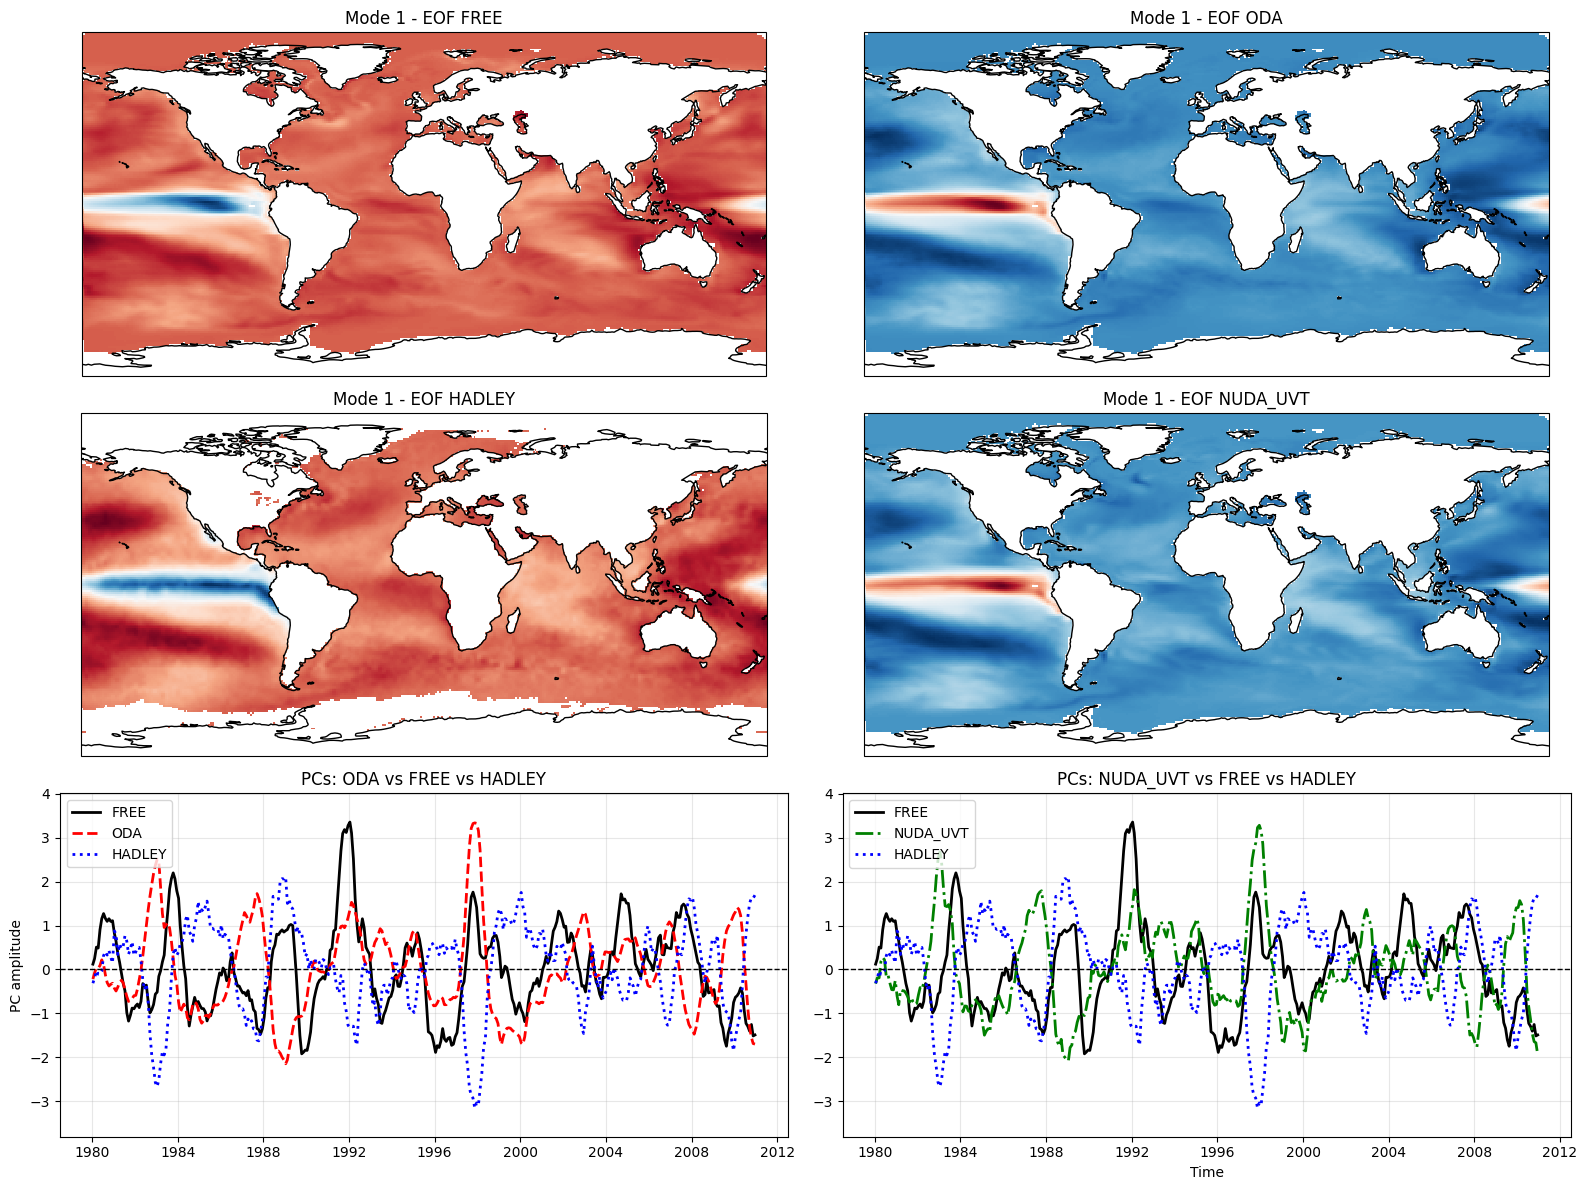

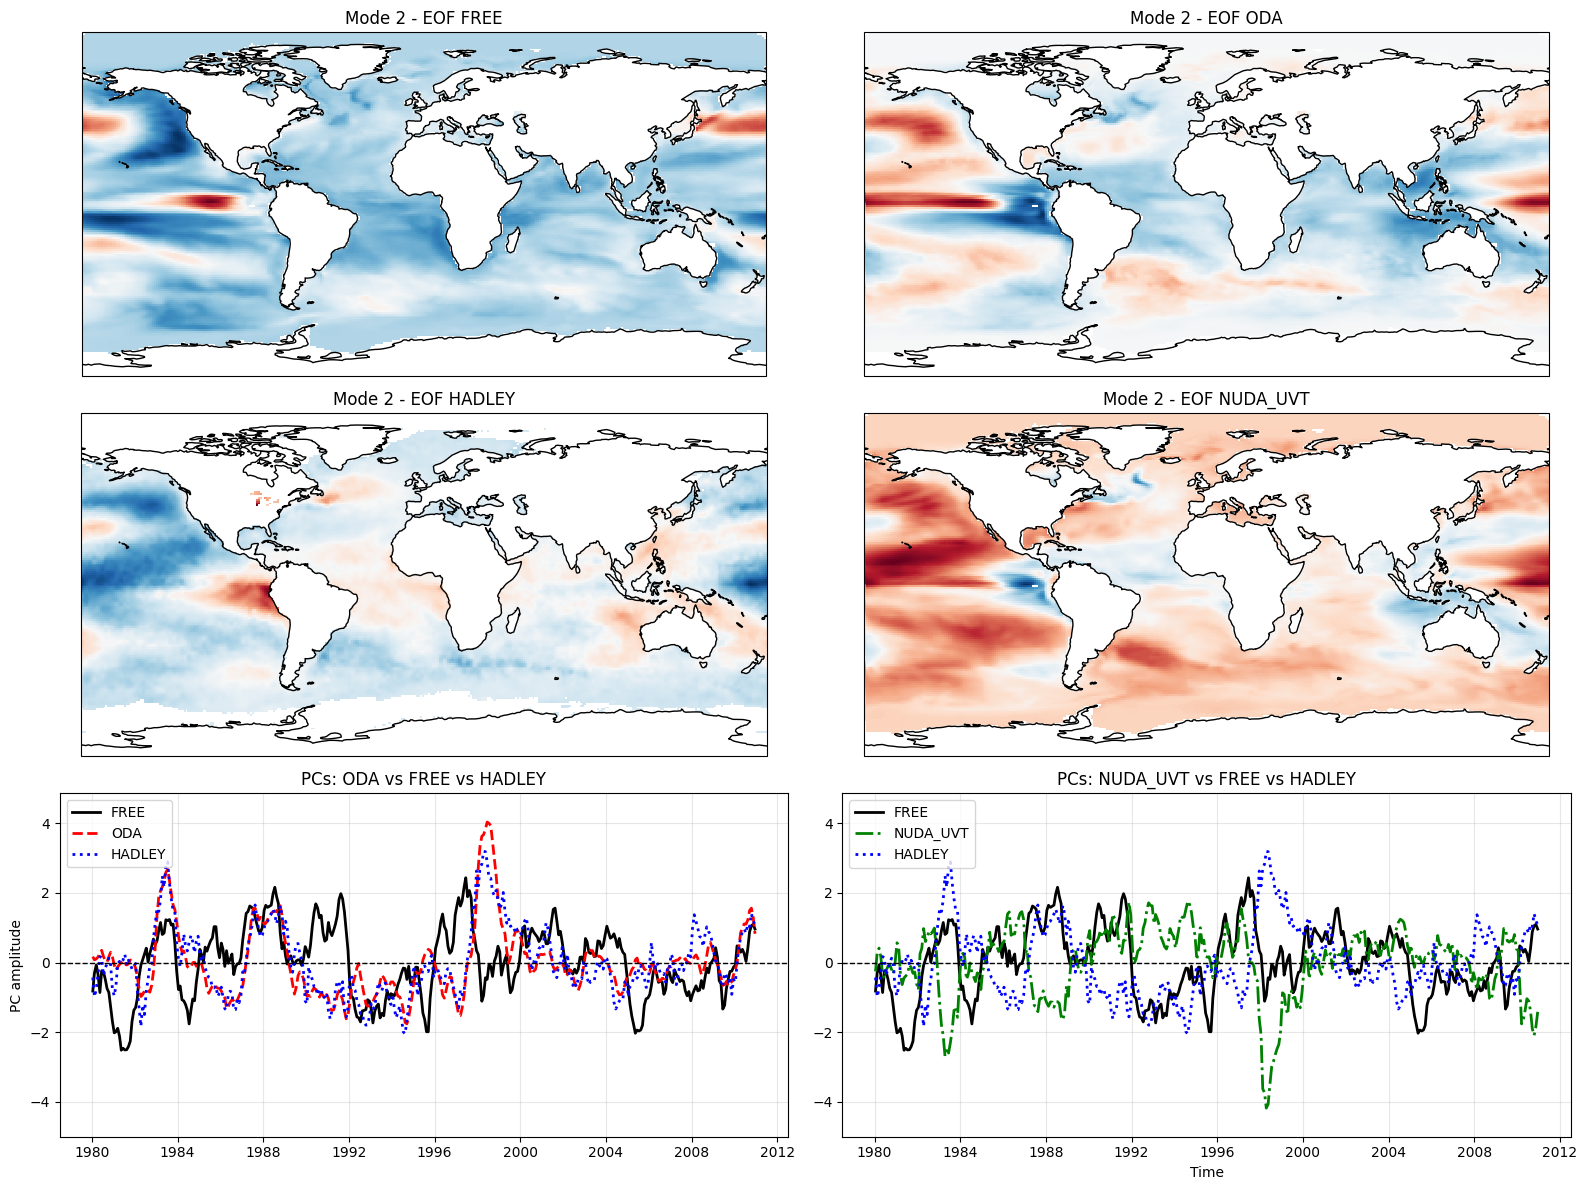

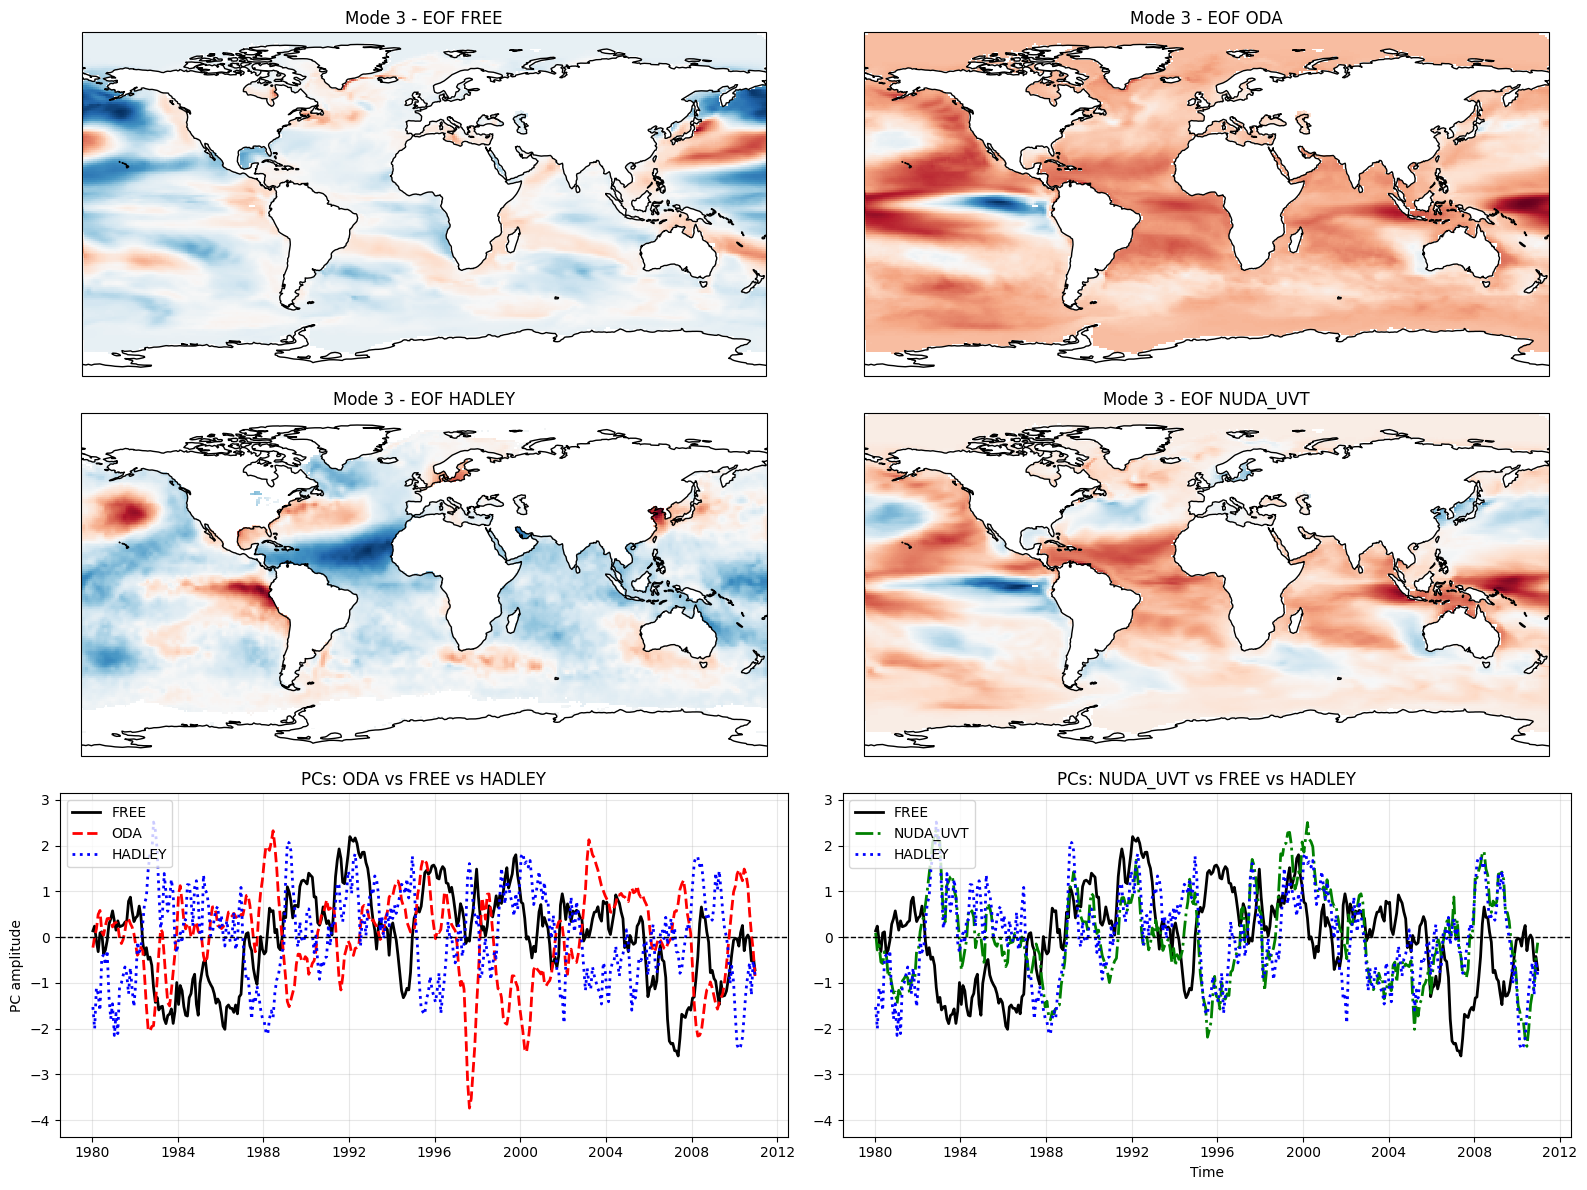

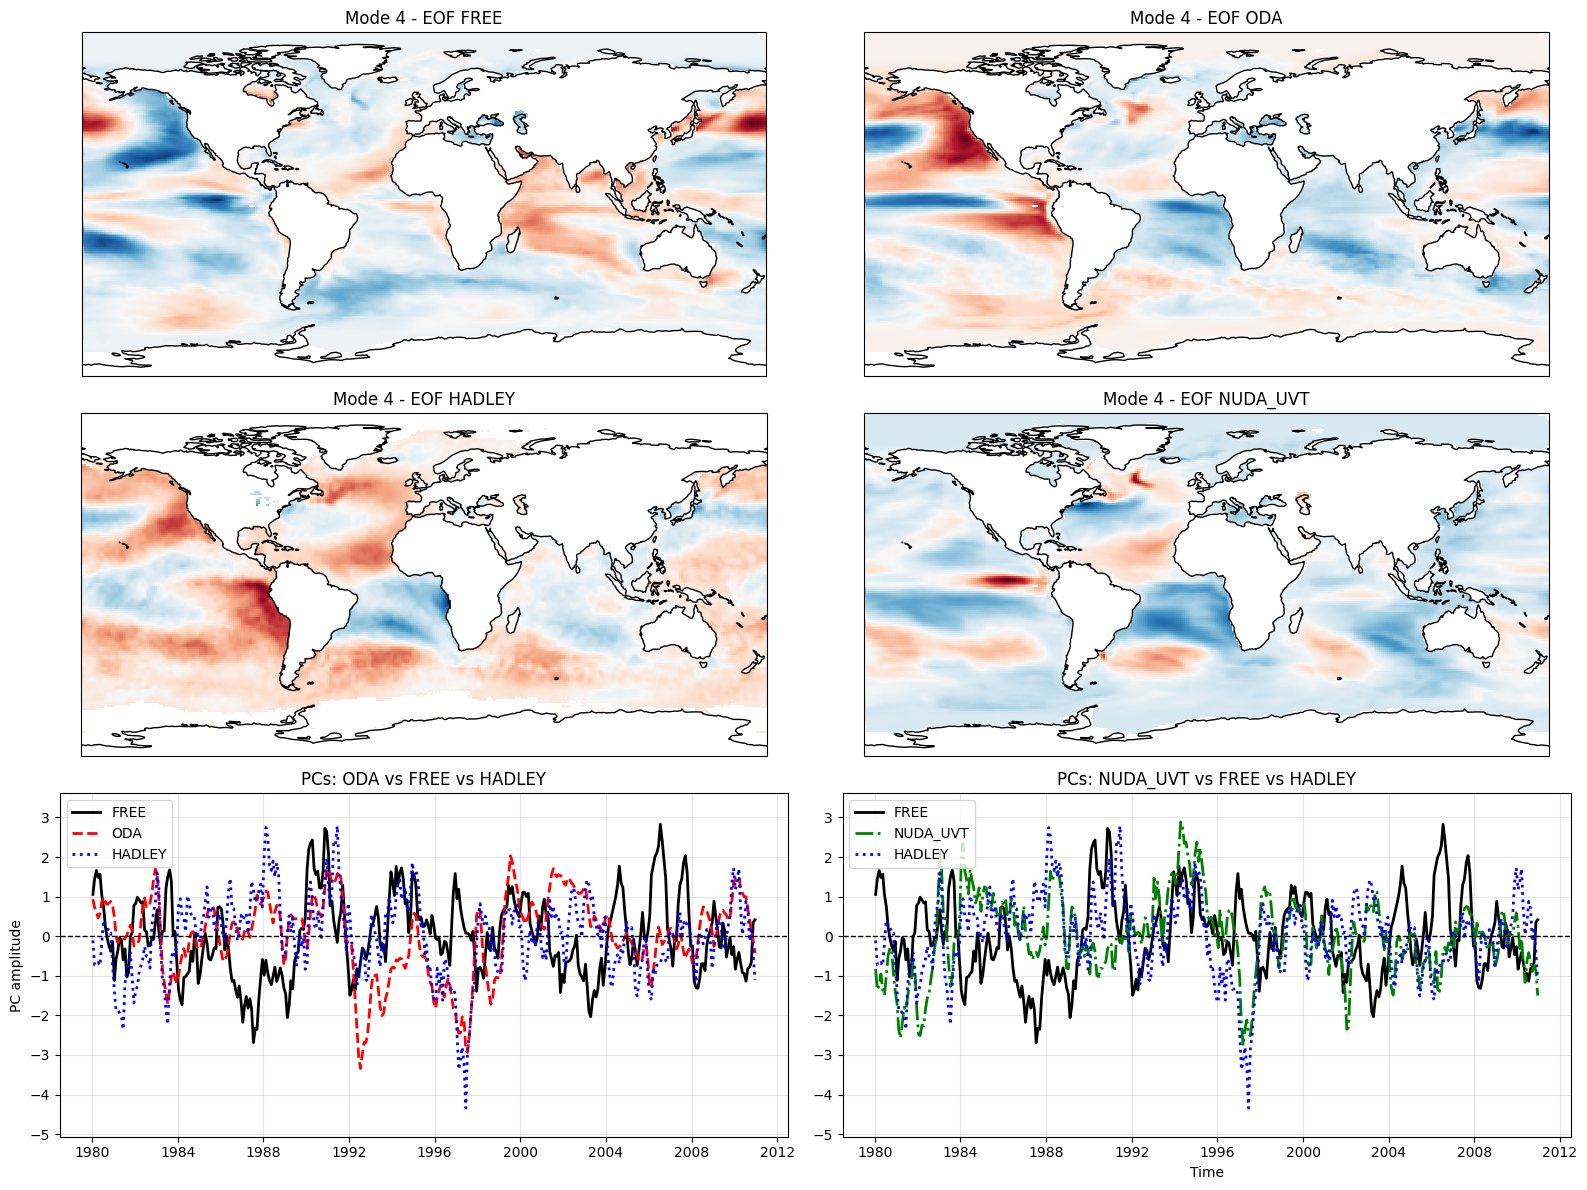

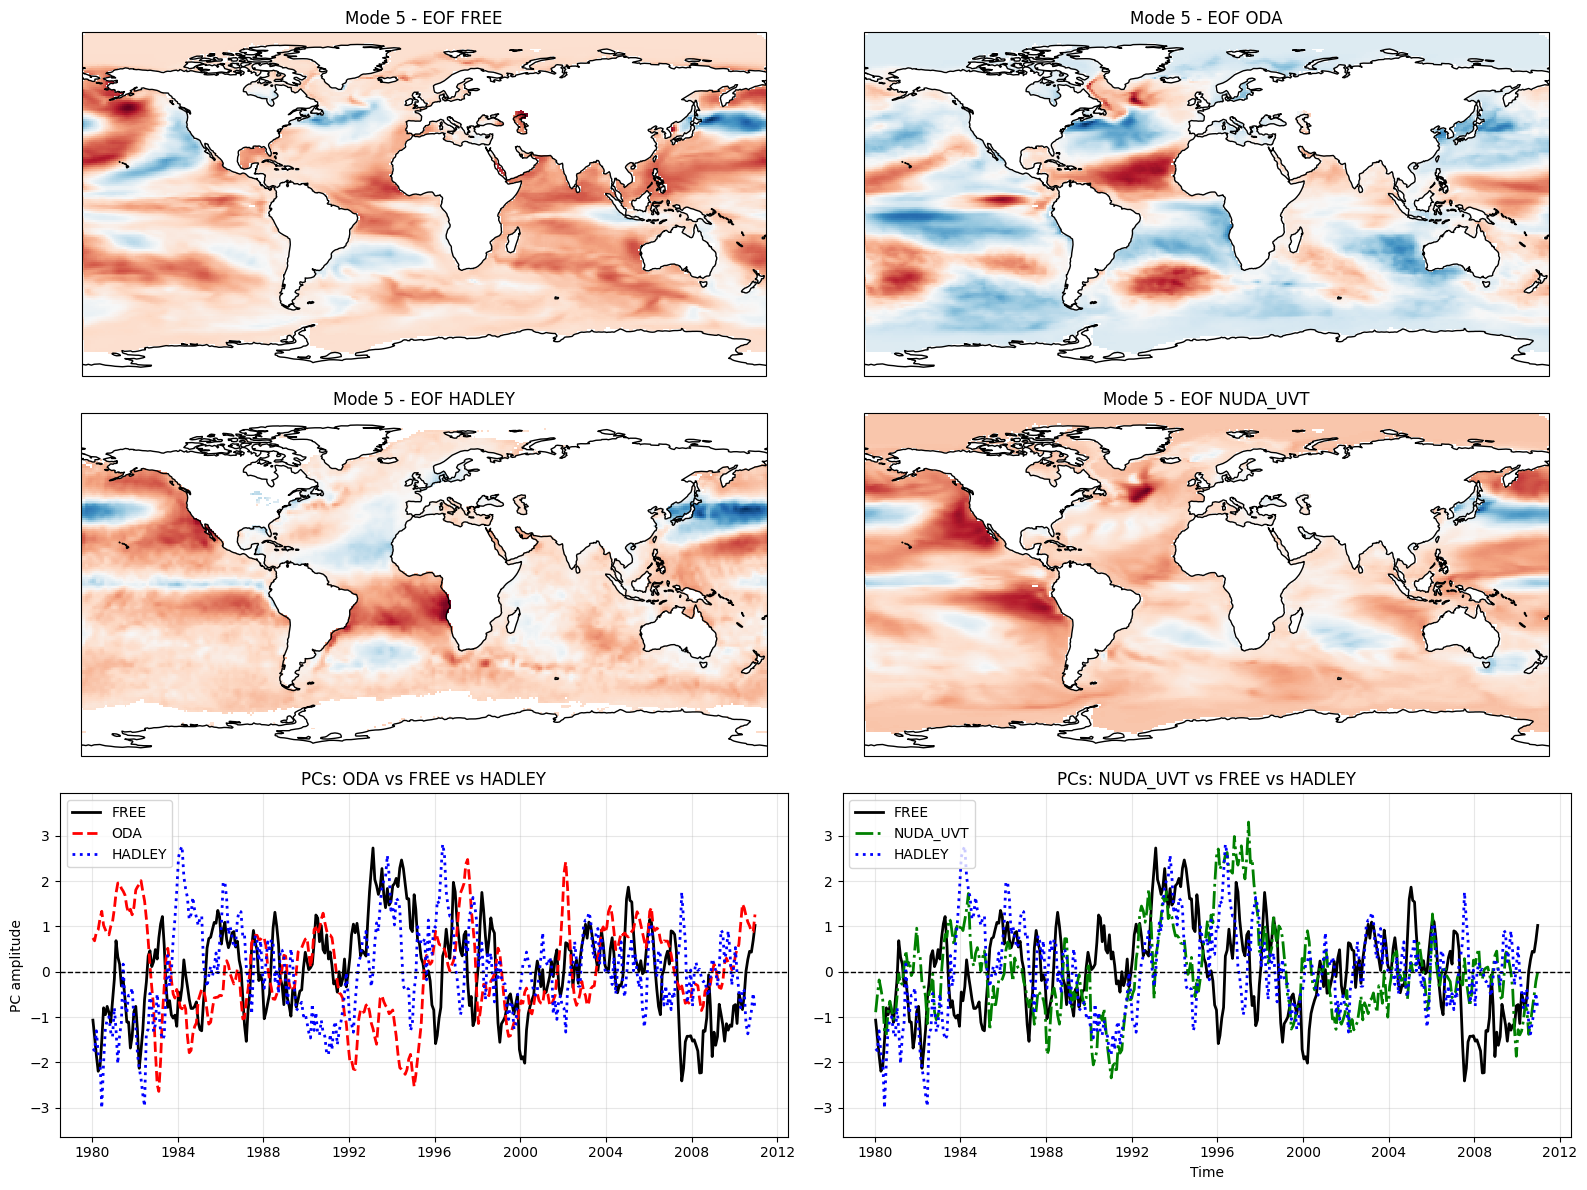

In [ ]:
for i in range(nmodes):

    fig = plt.figure(figsize=(16, 12))

    # ================= EOFs =================
    # --- FREE ---
    ax1 = fig.add_subplot(3, 2, 1, projection=ccrs.PlateCarree())
    ax1.pcolormesh(
        datasets["FREE"]["lon"], datasets["FREE"]["lat"],
        datasets["FREE"]["EOFs"][i],
        cmap=cmap, shading="auto", transform=ccrs.PlateCarree()
    )
    ax1.add_feature(cfeature.COASTLINE)
    ax1.set_title(f"Mode {i+1} - EOF FREE")

    # --- ODA ---
    ax2 = fig.add_subplot(3, 2, 2, projection=ccrs.PlateCarree())
    ax2.pcolormesh(
        datasets["ODA"]["lon"], datasets["ODA"]["lat"],
        datasets["ODA"]["EOFs"][i],
        cmap=cmap, shading="auto", transform=ccrs.PlateCarree()
    )
    ax2.add_feature(cfeature.COASTLINE)
    ax2.set_title(f"Mode {i+1} - EOF ODA")

    # --- HADLEY ---
    ax3 = fig.add_subplot(3, 2, 3, projection=ccrs.PlateCarree())
    ax3.pcolormesh(
        datasets["HADLEY"]["lon"], datasets["HADLEY"]["lat"],
        datasets["HADLEY"]["EOFs"][i],
        cmap=cmap, shading="auto", transform=ccrs.PlateCarree()
    )
    ax3.add_feature(cfeature.COASTLINE)
    ax3.set_title(f"Mode {i+1} - EOF HADLEY")

    # --- NUDA_UVT ---
    ax4 = fig.add_subplot(3, 2, 4, projection=ccrs.PlateCarree())
    ax4.pcolormesh(
        datasets["NUDA_UVT"]["lon"], datasets["NUDA_UVT"]["lat"],
        datasets["NUDA_UVT"]["EOFs"][i],
        cmap=cmap, shading="auto", transform=ccrs.PlateCarree()
    )
    ax4.add_feature(cfeature.COASTLINE)
    ax4.set_title(f"Mode {i+1} - EOF NUDA_UVT")

    # ================= PCs =================
    # --- Y limits spécifiques au mode i ---
    pc_values = []

    for key in ["FREE", "ODA", "HADLEY", "NUDA_UVT"]:
        pcs = datasets[key]["PCs"][:, i].values

        # ---------- Optionnel : standardiser le PC ----------
        pcs = pcs / np.std(pcs)  # diviser par écart-type du mode

        # ---------- Optionnel : forcer positif ----------
        if pcs.mean() < 0:  # si la moyenne est négative, inverser le signe
            pcs = -pcs

        # On stocke dans le dataset temporaire pour l'utilisation plus bas
        datasets[key]["PCs"][:, i] = pcs
        pc_values.append(pcs)

    pc_values = np.concatenate(pc_values)

    pc_min = pc_values.min()
    pc_max = pc_values.max()

    margin = 0.1 * (pc_max - pc_min)
    pc_ylim = (pc_min - margin, pc_max + margin)

    ax5 = fig.add_subplot(3, 2, 5)   # ODA vs FREE vs HADLEY
    ax6 = fig.add_subplot(3, 2, 6)   # NUDA_UVT vs FREE vs HADLEY

    # ---- Graphe 1 : ODA + FREE + HADLEY ----
    for key in ["FREE", "ODA", "HADLEY"]:
        time = convert_time(datasets[key]["time"].values)
        ax5.plot(
            time,
            datasets[key]["PCs"][:, i],
            label=key,
            **pc_styles[key]
        )

    ax5.axhline(0, color="k", linestyle="--", linewidth=1)
    ax5.set_ylim(pc_ylim)
    ax5.set_title("PCs: ODA vs FREE vs HADLEY")
    ax5.set_ylabel("PC amplitude")
    ax5.legend(loc="upper left")
    ax5.grid(True, alpha=0.3)

    # ---- Graphe 2 : NUDA_UVT + FREE + HADLEY ----
    for key in ["FREE", "NUDA_UVT", "HADLEY"]:
        time = convert_time(datasets[key]["time"].values)
        ax6.plot(
            time,
            datasets[key]["PCs"][:, i],
            label=key,
            **pc_styles[key]
        )

    ax6.axhline(0, color="k", linestyle="--", linewidth=1)
    ax6.set_ylim(pc_ylim)
    ax6.set_title("PCs: NUDA_UVT vs FREE vs HADLEY")
    ax6.set_xlabel("Time")
    ax6.legend(loc="upper left")
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


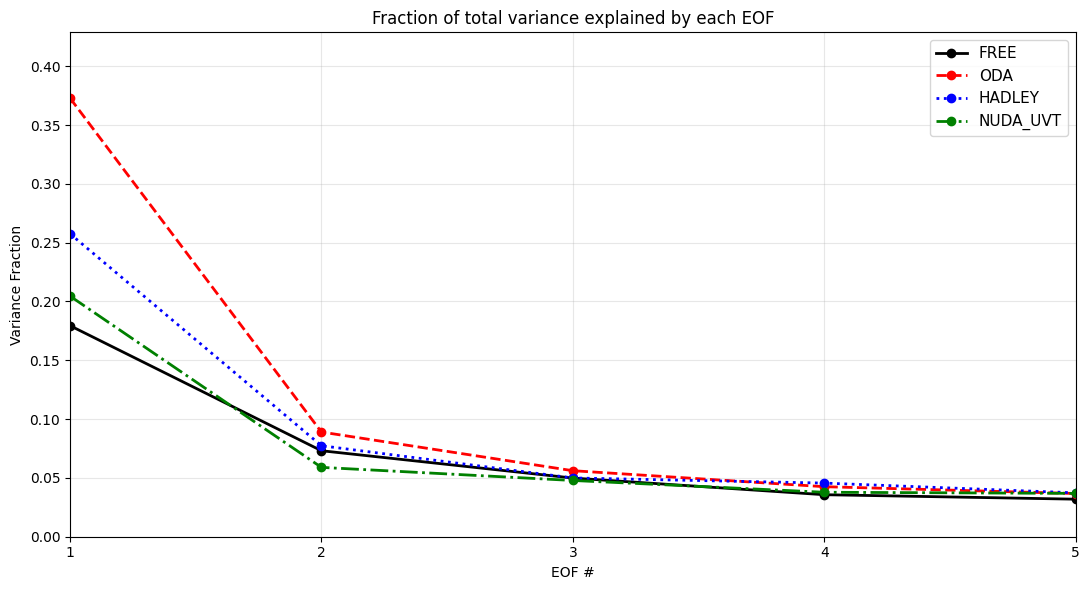

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Styles bien distincts
pc_styles = {
    "FREE":     {"color": "black",   "linestyle": "-",  "linewidth": 2, "marker": "o"},
    "ODA":      {"color": "red",     "linestyle": "--", "linewidth": 2, "marker": "o"},
    "HADLEY":   {"color": "blue",    "linestyle": ":",  "linewidth": 2, "marker": "o"},
    "NUDA_UVT": {"color": "green",   "linestyle": "-.", "linewidth": 2, "marker": "o"},
}

nmodes = 5
modes = np.arange(1, nmodes + 1)

plt.figure(figsize=(11, 6))

for name, ds in datasets.items():
    varfrac = ds["variance_fraction"].values[:nmodes]

    plt.plot(
        modes,
        varfrac,
        label=name,
        **pc_styles[name]
    )

plt.xticks(modes)
plt.xlabel("EOF #")
plt.ylabel("Variance Fraction")
plt.title("Fraction of total variance explained by each EOF")
plt.grid(alpha=0.3)

plt.legend(
    loc="upper right",
    frameon=True,
    fontsize=11
)

plt.xlim(1, nmodes)
plt.ylim(0, max(ds["variance_fraction"][:nmodes].max() for ds in datasets.values()) * 1.15)

plt.tight_layout()
plt.show()


In [ ]:
nmodes = 5
for name, ds in datasets.items():
    print(f"\n=== {name} dataset ===")

    varfrac = ds["variance_fraction"].values

    cum_sum = 0
    for i in range(nmodes):
        explained = round(varfrac[i] * 100, 2)
        cum_sum += explained

        print(
            f"EOF {i+1} explains {explained} %, "
            f"cumulative variance: {round(cum_sum, 2)} %"
        )


=== FREE dataset ===
EOF 1 explains 17.94 %, cumulative variance: 17.94 %
EOF 2 explains 7.31 %, cumulative variance: 25.25 %
EOF 3 explains 4.99 %, cumulative variance: 30.24 %
EOF 4 explains 3.57 %, cumulative variance: 33.81 %
EOF 5 explains 3.19 %, cumulative variance: 37.0 %

=== ODA dataset ===
EOF 1 explains 37.29 %, cumulative variance: 37.29 %
EOF 2 explains 8.9 %, cumulative variance: 46.19 %
EOF 3 explains 5.61 %, cumulative variance: 51.8 %
EOF 4 explains 4.25 %, cumulative variance: 56.05 %
EOF 5 explains 3.67 %, cumulative variance: 59.72 %

=== HADLEY dataset ===
EOF 1 explains 25.760000228881836 %, cumulative variance: 25.760000228881836 %
EOF 2 explains 7.739999771118164 %, cumulative variance: 33.5 %
EOF 3 explains 5.0 %, cumulative variance: 38.5 %
EOF 4 explains 4.559999942779541 %, cumulative variance: 43.060001373291016 %
EOF 5 explains 3.7300000190734863 %, cumulative variance: 46.790000915527344 %

=== NUDA_UVT dataset ===
EOF 1 explains 20.46 %, cumulative var



*   Structure générale


Pour l’ensemble des datasets (FREE, ODA, HADLEY, NUDA_UVT), la variabilité est très fortement dominée par le premier mode EOF, qui explique à lui seul plus de 80 % de la variance totale.


*  Dataset FREE

EOF1 explique 82.0 % de la variance totale.
Les 5 premiers EOFs cumulent ≈ 91.4 % de la variance.
La décroissance rapide après EOF1 suggère que le signal dominant est bien capturé, mais que les structures secondaires restent limitées.

* Dataset ODA

EOF1 explique 88.4 %, soit la valeur **la plus élevée** parmi tous les datasets.
Les 3 premiers modes expliquent déjà ≈ 96 % de la variance.
Les modes supérieurs (EOF4–EOF5) deviennent quasi négligeables.

* Dataset HADLEY

EOF1 explique 87.9 % de la variance, très proche de ODA.
Les 5 premiers EOFs expliquent ≈ 95.7 % de la variance.

**=> La similarité entre HADLEY et ODA suggère que l’assimilation améliore la représentation des structures dominantes observées.**

* Dataset NUDA_UVT

EOF1 explique 81.5 %, valeur la plus faible pour le premier mode.
Les 5 premiers EOFs expliquent ≈ 91.6 % de la variance.
La distribution de la variance est plus progressive.

**=> NUDA_UVT conserve davantage de variabilité dans les modes secondaires, ce qui peut refléter une meilleure représentation de structures de méso-échelle ou de variabilité régionale.**

**Calcul de metrics**

1️⃣ Corrélation spatiale entre EOFs
Principe : comparer la structure spatiale des EOFs ODA et Hadley.
Comment : calculer le coefficient de corrélation de Pearson entre les EOFs correspondants (mode par mode) sur toutes les grilles valides.
Exemple :


r = sigma(EOFODA - EÖFODA) (EOFhadley - EÖF Hadley)/ sqr( sigma(EOFODA - EÖFODA)2 signa (EOF Hadley - EÖF Hadley)2)


Référence :
Deser et al., 2010, J. Climate, “Spatial patterns of climate variability from observational datasets.”

In [ ]:
def interp_to_hadley(eof, lon_src, lat_src, lon_had, lat_had):
    da = xr.DataArray(
        eof,
        dims=("lat", "lon"),
        coords={"lat": lat_src, "lon": lon_src}
    )
    da_interp = da.interp(
        lon=lon_had,
        lat=lat_had,
        method="linear"
    )
    return da_interp.values


In [ ]:
def spatial_corr_eof_common_grid(eof_x, eof_h,
                                 lon_x, lat_x,
                                 lon_h, lat_h):
    """
    Corrélation spatiale EOF après interpolation sur grille HADLEY
    """

    eof_x_interp = interp_to_hadley(
        eof_x, lon_x, lat_x, lon_h, lat_h
    )

    x = eof_x_interp.flatten()
    y = eof_h.flatten()

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    x = x - x.mean()
    y = y - y.mean()

    r = np.sum(x * y) / np.sqrt(np.sum(x**2) * np.sum(y**2))
    return np.abs(r)


In [ ]:
nmodes = 5

results = {"FREE": [], "ODA": [], "NUDA_UVT": []}

lon_h = datasets["HADLEY"]["lon"].values
lat_h = datasets["HADLEY"]["lat"].values

for i in range(nmodes):

    eof_had = datasets["HADLEY"]["EOFs"][i].values

    for key in ["FREE", "ODA", "NUDA_UVT"]:
        eof_x = datasets[key]["EOFs"][i].values
        lon_x = datasets[key]["lon"].values
        lat_x = datasets[key]["lat"].values

        r = spatial_corr_eof_common_grid(
            eof_x, eof_had,
            lon_x, lat_x,
            lon_h, lat_h
        )

        results[key].append(r)


In [ ]:
df_corr = pd.DataFrame(
    results,
    index=[f"Mode {i+1}" for i in range(nmodes)]
)
df_corr


,FREE,ODA,NUDA_UVT
Mode 1,0.913657,0.966713,0.950892
Mode 2,0.003765,0.828634,0.850097
Mode 3,0.031399,0.606990,0.747500
Mode 4,0.425039,0.662155,0.649190
Mode 5,0.040317,0.198705,0.511143


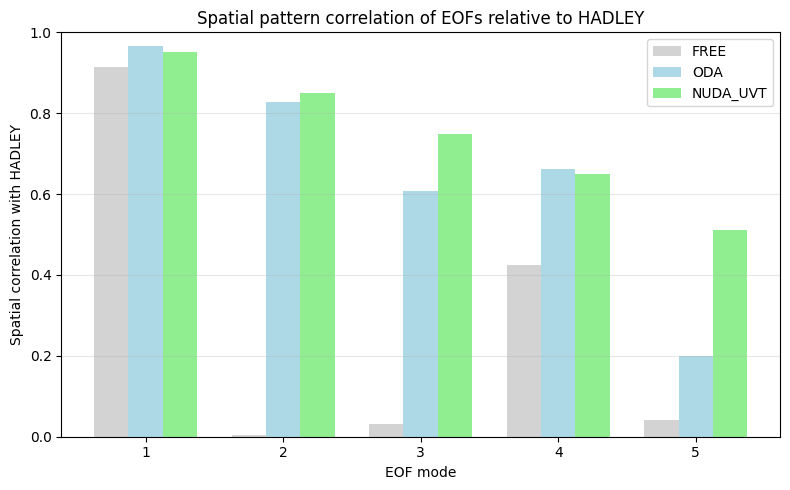

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# df_corr = DataFrame obtenu précédemment
# index : Mode 1, Mode 2, ...
# colonnes : FREE, ODA, NUDA_UVT

modes = np.arange(1, len(df_corr) + 1)
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(modes - width, df_corr["FREE"], width, label="FREE", color="lightgray")
ax.bar(modes,         df_corr["ODA"],  width, label="ODA", color="lightblue")
ax.bar(modes + width, df_corr["NUDA_UVT"], width, label="NUDA_UVT", color="lightgreen")

ax.set_xlabel("EOF mode")
ax.set_ylabel("Spatial correlation with HADLEY")
ax.set_title("Spatial pattern correlation of EOFs relative to HADLEY")
ax.set_xticks(modes)
ax.set_ylim(0, 1)

ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


Aspect	Conclusion

Mode dominant (1)	Très robuste, peu sensible à l’assimilation
Modes 2 & 4	Assimilation améliore globalement la cohérence spatiale

FREE vs assimilé	FREE est souvent moins cohérent sauf pour mode 3

ODA vs NUDA:	NUDA légèrement meilleur sur certains modes

Modes élevés 5:	Faible robustesse, bruit dominant

2️⃣ Corrélation temporelle des PCs
Principe : comparer l’évolution temporelle des PCs correspondants.
Comment : calculer le coefficient de corrélation de Pearson entre PC ODA et PC Hadley pour chaque mode.
Note : il faut s’assurer que les deux séries sont sur le même calendrier (ex. conversion en pd.DatetimeIndex comme on a fait).
Référence :
Alexander et al., 2002, J. Climate, “Evaluation of observational vs modeled principal components.”

In [ ]:
import pandas as pd
import numpy as np

nmodes = 5
results_pc = {"FREE": [], "ODA": [], "NUDA_UVT": []}

for i in range(nmodes):
    # PC de référence HADLEY
    pc_had = datasets["HADLEY"]["PCs"][:, i].values

    for key in ["FREE", "ODA", "NUDA_UVT"]:
        pc_x = datasets[key]["PCs"][:, i].values

        # Vérifier que les deux ont la même taille
        if len(pc_x) != len(pc_had):
            min_len = min(len(pc_x), len(pc_had))
            pc_x = pc_x[:min_len]
            pc_had = pc_had[:min_len]

        # Calcul de la corrélation
        r = np.corrcoef(pc_x, pc_had)[0, 1]
        results_pc[key].append(r)

# Créer un DataFrame
df_pc_corr = pd.DataFrame(
    results_pc,
    index=[f"Mode {i+1}" for i in range(nmodes)]
)

df_pc_corr


,FREE,ODA,NUDA_UVT
Mode 1,-0.149806,-0.955832,-0.975718
Mode 2,0.175354,0.888535,-0.919641
Mode 3,-0.097965,-0.661718,0.847911
Mode 4,-0.139022,0.594361,0.645896
Mode 5,0.153373,-0.279584,0.556797


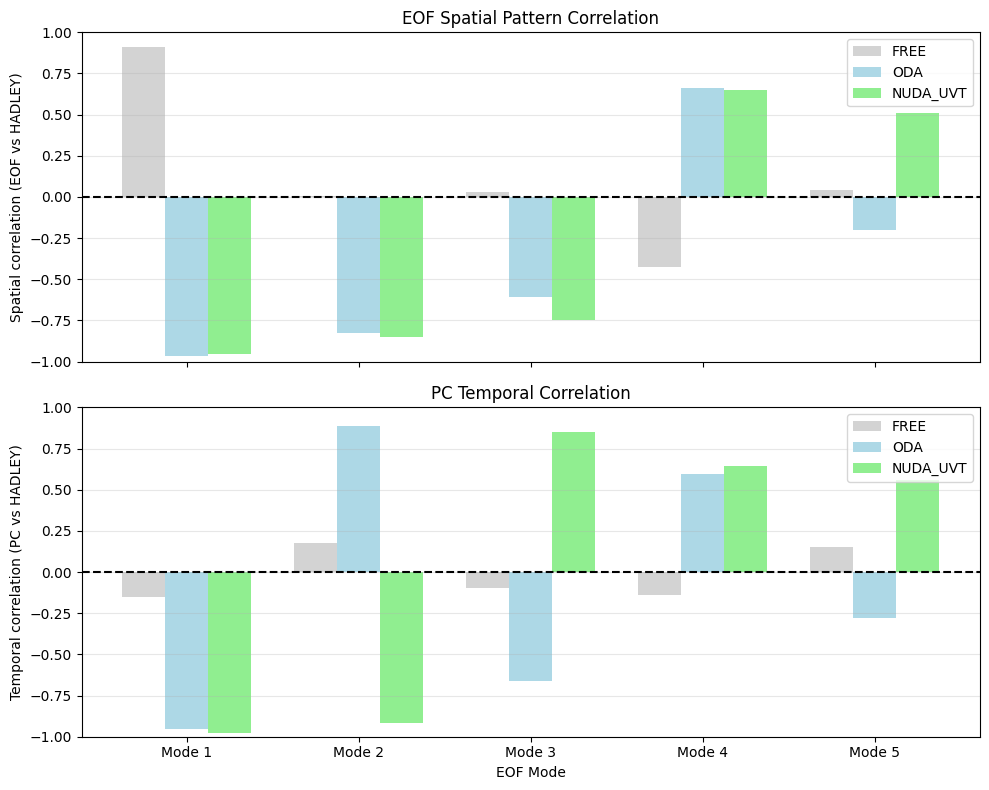

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

modes = np.arange(1, len(df_corr)+1)
width = 0.25

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8), sharex=True)

# --- Top : EOFs spatial correlation (avec valeurs négatives) ---
ax1.bar(modes - width, df_corr["FREE"], width, label="FREE", color="lightgray")
ax1.bar(modes, df_corr["ODA"], width, label="ODA", color="lightblue")
ax1.bar(modes + width, df_corr["NUDA_UVT"], width, label="NUDA_UVT", color="lightgreen")

ax1.set_ylabel("Spatial correlation (EOF vs HADLEY)")
ax1.set_title("EOF Spatial Pattern Correlation")
ax1.set_ylim(-1, 1)  # afficher les négatifs aussi
ax1.axhline(0, color='k', linestyle='--')  # ligne zéro
ax1.legend(loc="upper right")
ax1.grid(axis="y", alpha=0.3)

# --- Bottom : PCs temporal correlation (avec valeurs négatives) ---
ax2.bar(modes - width, df_pc_corr["FREE"], width, label="FREE", color="lightgray")
ax2.bar(modes, df_pc_corr["ODA"], width, label="ODA", color="lightblue")
ax2.bar(modes + width, df_pc_corr["NUDA_UVT"], width, label="NUDA_UVT", color="lightgreen")

ax2.set_xlabel("EOF Mode")
ax2.set_ylabel("Temporal correlation (PC vs HADLEY)")
ax2.set_title("PC Temporal Correlation")
ax2.set_ylim(-1, 1)  # afficher les négatifs aussi
ax2.axhline(0, color='k', linestyle='--')  # ligne zéro
ax2.legend(loc="upper right")
ax2.grid(axis="y", alpha=0.3)

plt.xticks(modes, [f"Mode {i}" for i in modes])
plt.tight_layout()
plt.show()


3️⃣ Root Mean Square Error (RMSE) des EOFs et des PCs
Principe : mesurer l’erreur quadratique moyenne entre ODA et Hadley.
Formules :
RMSE
racine (1/N sigma(EOFoda-eofhad)2)

Référence :
Trenberth et al., 1997, J. Climate, “Error metrics in climate data comparison.”

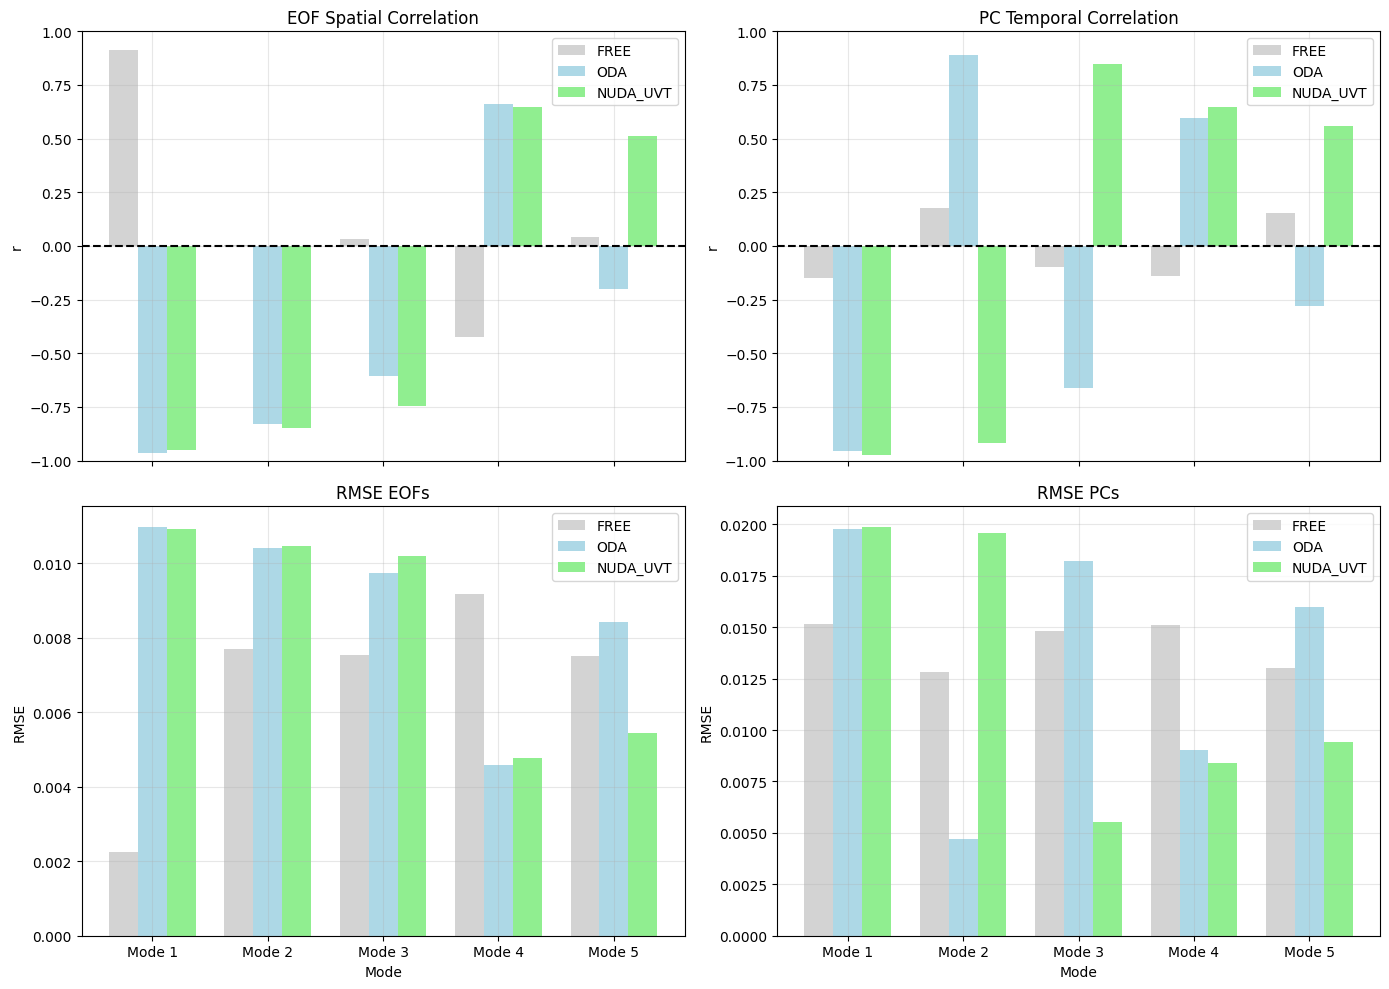

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1️⃣ Fonctions utilitaires
# ----------------------------

def convert_time_safe(time_array):
    """Convertir en pd.DatetimeIndex"""
    if isinstance(time_array[0], pd.Timestamp):
        return pd.to_datetime(time_array)
    elif isinstance(time_array[0], np.datetime64):
        return pd.to_datetime(time_array)
    else:  # cftime
        return pd.to_datetime([t.strftime("%Y-%m-%d") for t in time_array])

def spatial_corr_eof(eof_x, eof_h):
    """Corrélation spatiale EOF (mode flatten) après interpolation sur grille HADLEY"""
    # Interpoler eof_x sur la grille de eof_h si ce n'est pas déjà la même
    if eof_x.shape != eof_h.shape:
        eof_x = eof_x.interp(lat=eof_h['lat'], lon=eof_h['lon'], method='linear')

    x = eof_x.values.flatten()
    h = eof_h.values.flatten()
    mask = np.isfinite(x) & np.isfinite(h)
    x = x[mask]
    h = h[mask]
    return np.corrcoef(x, h)[0,1]

def temporal_corr_pc(pc_x, time_x, pc_h, time_h, freq='MS'):
    """Corrélation temporelle PC après resampling et alignement"""
    pc_x_s = pd.Series(pc_x, index=convert_time_safe(time_x))
    pc_h_s = pd.Series(pc_h, index=convert_time_safe(time_h))

    pc_x_s = pc_x_s.resample(freq).mean()
    pc_h_s = pc_h_s.resample(freq).mean()

    common_index = pc_x_s.index.intersection(pc_h_s.index)
    pc_x_aligned = pc_x_s.loc[common_index]
    pc_h_aligned = pc_h_s.loc[common_index]

    if len(pc_x_aligned) == 0:
        return np.nan

    return pc_x_aligned.corr(pc_h_aligned)

def rmse_eof(eof_x, eof_h):
    """RMSE EOF après interpolation sur grille HADLEY"""
    if eof_x.shape != eof_h.shape:
        eof_x = eof_x.interp(lat=eof_h['lat'], lon=eof_h['lon'], method='linear')
    x = eof_x.values.flatten()
    h = eof_h.values.flatten()
    mask = np.isfinite(x) & np.isfinite(h)
    x = x[mask]
    h = h[mask]
    return np.sqrt(np.mean((x - h)**2))

# Avant calcul du RMSE PC, diviser par 100
def rmse_pc(pc_x, time_x, pc_h, time_h, freq='MS', scale=100.0):
    pc_x_s = pd.Series(pc_x/scale, index=convert_time_safe(time_x))
    pc_h_s = pd.Series(pc_h/scale, index=convert_time_safe(time_h))
    pc_x_s = pc_x_s.resample(freq).mean()
    pc_h_s = pc_h_s.resample(freq).mean()

    common_index = pc_x_s.index.intersection(pc_h_s.index)
    pc_x_aligned = pc_x_s.loc[common_index]
    pc_h_aligned = pc_h_s.loc[common_index]

    if len(pc_x_aligned) == 0:
        return np.nan

    return np.sqrt(np.mean((pc_x_aligned - pc_h_aligned)**2))


# ----------------------------
# 2️⃣ Préparer les datasets
# ----------------------------

datasets_keys = ["FREE", "ODA", "NUDA_UVT"]
nmodes = 5

# Exemple : datasets["FREE"]["EOFs"], datasets["FREE"]["PCs"], datasets["FREE"]["time"], etc.
# datasets["HADLEY"]["EOFs"], datasets["HADLEY"]["PCs"], datasets["HADLEY"]["time"]

# ----------------------------
# 3️⃣ Calculs
# ----------------------------

# Corrélation spatiale EOFs
df_corr = pd.DataFrame(index=[f"Mode {i+1}" for i in range(nmodes)], columns=datasets_keys)
for i in range(nmodes):
    eof_h = datasets["HADLEY"]["EOFs"][i,:,:]
    for key in datasets_keys:
        eof_x = datasets[key]["EOFs"][i,:,:]
        df_corr.loc[f"Mode {i+1}", key] = spatial_corr_eof(eof_x, eof_h)

# Corrélation temporelle PCs
df_pc_corr = pd.DataFrame(index=[f"Mode {i+1}" for i in range(nmodes)], columns=datasets_keys)
for i in range(nmodes):
    pc_h = datasets["HADLEY"]["PCs"][:,i]
    time_h = datasets["HADLEY"]["time"].values
    for key in datasets_keys:
        pc_x = datasets[key]["PCs"][:,i]
        time_x = datasets[key]["time"].values
        df_pc_corr.loc[f"Mode {i+1}", key] = temporal_corr_pc(pc_x, time_x, pc_h, time_h, freq='MS')

# RMSE EOFs
df_rmse_eof = pd.DataFrame(index=[f"Mode {i+1}" for i in range(nmodes)], columns=datasets_keys)
for i in range(nmodes):
    eof_h = datasets["HADLEY"]["EOFs"][i,:,:]
    for key in datasets_keys:
        eof_x = datasets[key]["EOFs"][i,:,:]
        df_rmse_eof.loc[f"Mode {i+1}", key] = rmse_eof(eof_x, eof_h)

# RMSE PCs
df_rmse_pc = pd.DataFrame(index=[f"Mode {i+1}" for i in range(nmodes)], columns=datasets_keys)
for i in range(nmodes):
    pc_h = datasets["HADLEY"]["PCs"][:,i]
    time_h = datasets["HADLEY"]["time"].values
    for key in datasets_keys:
        pc_x = datasets[key]["PCs"][:,i]
        time_x = datasets[key]["time"].values
        df_rmse_pc.loc[f"Mode {i+1}", key] = rmse_pc(pc_x, time_x, pc_h, time_h, freq='MS')

# ----------------------------
# 4️⃣ Figure synthèse
# ----------------------------

colors = ["lightgray", "lightblue", "lightgreen"]

fig, axs = plt.subplots(2, 2, figsize=(14,10), sharex=True)

# Top-left : EOF spatial correlation
ax = axs[0,0]
for idx, key in enumerate(datasets_keys):
    ax.bar(modes + (idx-1)*width, df_corr[key].astype(float), width, label=key,
           color=colors[idx])
ax.axhline(0, color='k', linestyle='--')
ax.set_ylim(-1,1)
ax.set_title("EOF Spatial Correlation")
ax.set_ylabel("r")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

# Top-right : PC temporal correlation
ax = axs[0,1]
for idx, key in enumerate(datasets_keys):
    ax.bar(modes + (idx-1)*width, df_pc_corr[key].astype(float), width, label=key,
           color=colors[idx])
ax.axhline(0, color='k', linestyle='--')
ax.set_ylim(-1,1)
ax.set_title("PC Temporal Correlation")
ax.set_ylabel("r")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

# Bottom-left : RMSE EOF
ax = axs[1,0]
for idx, key in enumerate(datasets_keys):
    ax.bar(modes + (idx-1)*width, df_rmse_eof[key].astype(float), width, label=key,
           color=colors[idx])
ax.set_title("RMSE EOFs")
ax.set_ylabel("RMSE")
ax.set_xlabel("Mode")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

# Bottom-right : RMSE PC
ax = axs[1,1]
for idx, key in enumerate(datasets_keys):
    ax.bar(modes + (idx-1)*width, df_rmse_pc[key].astype(float), width, label=key,
           color=colors[idx])
ax.set_title("RMSE PCs")
ax.set_ylabel("RMSE")
ax.set_xlabel("Mode")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

plt.xticks(modes, [f"Mode {i}" for i in modes])
plt.tight_layout()
plt.show()


**=== RMSE EOFs ===**

Modes dominants (1,2) :
toutes les simulations reproduisent très bien HADLEY.

Modes intermédiaires (3,4) :

FREE et NUDA_UVT reproduisent mieux certains modes que ODA.
ODA a des difficultés pour le mode 4.

Modes supérieurs (5) :

reproduction plus difficile, NUDA_UVT reste le plus performant.
Globalement, NUDA_UVT semble offrir la meilleure cohérence avec HADLEY sur les modes intermédiaires et élevés

**=== RMSE PCs ===**

Modes dominants (1,2) : ODA et NUDA_UVT améliorent ou égalent FREE, surtout pour le mode 2.
Modes intermédiaires et supérieurs (3,4,5) :
NUDA_UVT est clairement meilleur, en particulier pour les modes 4 et 5.
ODA peut être moins performant que FREE pour certains modes (mode 3 et 4).

In [ ]:
print("=== RMSE EOFs ===")
print(df_rmse_eof.round(4))

=== RMSE EOFs ===
            FREE       ODA  NUDA_UVT
Mode 1  0.002242  0.010971  0.010918
Mode 2  0.007688  0.010411  0.010449
Mode 3  0.007522  0.009726  0.010178
Mode 4  0.009157  0.004568  0.004761
Mode 5  0.007508  0.008409  0.005444


In [ ]:
print("=== RMSE PCs ===")
print(df_rmse_pc.round(4))


=== RMSE PCs ===
            FREE       ODA  NUDA_UVT
Mode 1  0.015164  0.019778  0.019878
Mode 2  0.012842  0.004722  0.019594
Mode 3  0.014819   0.01823  0.005515
Mode 4  0.015093  0.009007  0.008416
Mode 5  0.013013  0.015997  0.009415
